In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from torchvision.transforms import ToTensor
from torchvision.io import decode_image

from torch import nn
from torch import optim
import torch.nn.functional as activation

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import os

#gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


csv_path = "/kaggle/input/datasets/ginoleone117/coco-cropped/cropped_coco.csv"
images_path = "/kaggle/input/datasets/ginoleone117/cropped-coco-images/cropped_coco_images"

Helper cell just to get index of columns when needed #WARNING could change if csv file columns are removed, this csv file is downloaded from my local computer... Not from the output of the coco_preprocessing notebook

In [2]:
df = pd.read_csv(csv_path)
print(df.head)
index = df.columns.get_loc("file_name")
print(index)

<bound method NDFrame.head of       name_bicycle  name_bus  name_car  name_person  name_truck  image_index  \
0              0.0       0.0       1.0          0.0         0.0            2   
1              0.0       1.0       0.0          0.0         0.0            3   
2              0.0       0.0       0.0          0.0         1.0            4   
3              0.0       0.0       0.0          1.0         0.0            0   
4              0.0       0.0       0.0          1.0         0.0            0   
...            ...       ...       ...          ...         ...          ...   
1541           0.0       0.0       1.0          0.0         0.0            2   
1542           0.0       0.0       0.0          1.0         0.0            0   
1543           0.0       0.0       0.0          1.0         0.0            0   
1544           0.0       0.0       1.0          0.0         0.0            2   
1545           0.0       0.0       1.0          0.0         0.0            2   

         

<Axes: >

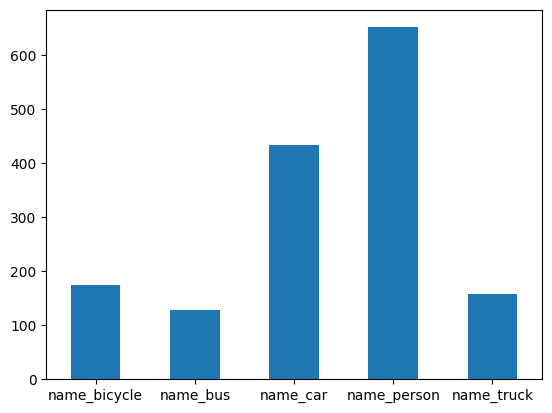

In [3]:
#plot the label distribution of the entire dataframe before splitting
encoded_columns = ["name_bicycle", "name_bus", "name_car", "name_person", "name_truck"]
sum_labels = df[encoded_columns].sum()
sum_labels.plot.bar(x = "labels", y = "count", rot = 0)

In [4]:
#split into train and val:
df_train, df_val = train_test_split(
    df,
    test_size = .15,
    shuffle = True,
    stratify = df[encoded_columns],
    random_state = 42
)

<Axes: >

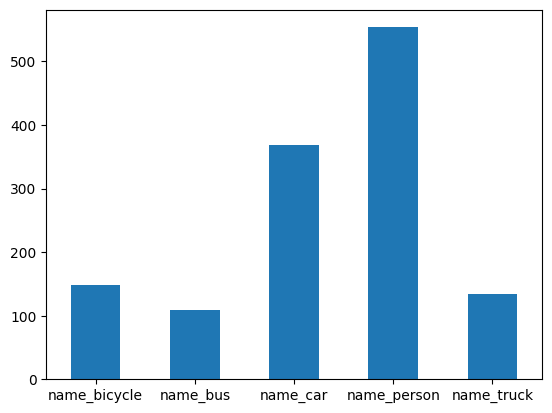

In [5]:
sum_labels_train = df_train[encoded_columns].sum()
sum_labels_train.plot.bar(x = "labels", y = "count", rot = 0)

<Axes: >

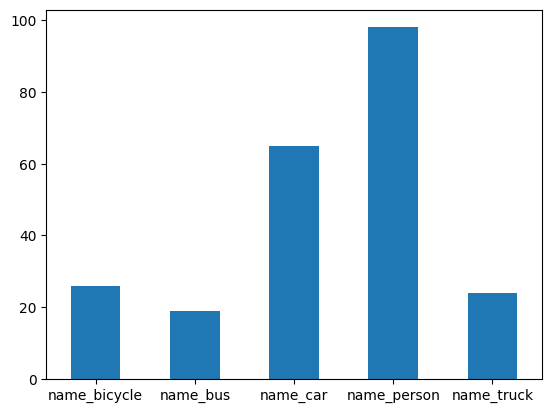

In [6]:
sum_labels_val = df_val[encoded_columns].sum()
sum_labels_val.plot.bar(x = "labels", y = "count", rot = 0)

In [7]:
#Image transformations

image_transform_required = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

image_augmentations = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.4, 0.4, 0.2, 0.1),
    transforms.RandomResizedCrop(244, scale=(0.8, 1.0))
])

#encoded_column_names = ["encoder__name_bus", "encoder__name_car", "encoder__name_person", "encoder__name_truck"]

Augmentation that gets applied to the image before it is passed into the CNN

In [8]:
#Dataset class
class CocoVehicleDataset(Dataset):
    __slots__ = "dataframe", "root_directory", "required_transform", "agumentations", "labels"
    
    def __init__(self, dataframe, root_directory, required_transform, augmentations = None):
        """
        Initializes csv file
        """
        self.coco_frame = dataframe
        self.root_directory = root_directory
        self.required_transform = required_transform
        self.augmentations = augmentations
        
        self.labels = torch.tensor(self.coco_frame.iloc[:, 0:5].values, dtype=torch.float32)


    def __len__(self):
        return len(self.coco_frame)

    def __getitem__(self, row_index):
        """
        This gets the specific image sample corresponding to the 
        row of the csv file
        """
        if torch.is_tensor(row_index):
            row_index = row_index.tolist()

        
        #the full path to the image
        img_path = os.path.join(self.root_directory, self.coco_frame.iloc[row_index, 14])
                     
        image = decode_image(img_path)
 
        label = self.labels[row_index]
    
        #apply image augmentations
        if self.augmentations is not None:
            image = self.augmentations(image)

        #convert to 244px x 244px width/height
        image = self.required_transform(image)
        #return tuple that contains the image and its corresponding label(category), label is converted to tensor
        return image, torch.tensor(label, dtype = torch.float)
        

Dataset class holds and extracts CSV rows and augmented images corresponding to the rows. 

In [9]:
#initialize datasets and dataloaders for trianing and validation set
training_coco_set = CocoVehicleDataset(df_train, images_path, image_transform_required, image_augmentations)
validation_coco_set = CocoVehicleDataset(df_val, images_path, image_transform_required)

training_data_loader = DataLoader(training_coco_set, batch_size = 32, shuffle = True)
validation_data_loader = DataLoader(validation_coco_set, batch_size = 32, shuffle = False)

/tmp/ipykernel_23/396129356.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(label, dtype = torch.float)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4842881..1.8731157].


Features batch shape: torch.Size([32, 3, 256, 256])
Labels batch shape: torch.Size([32, 5])


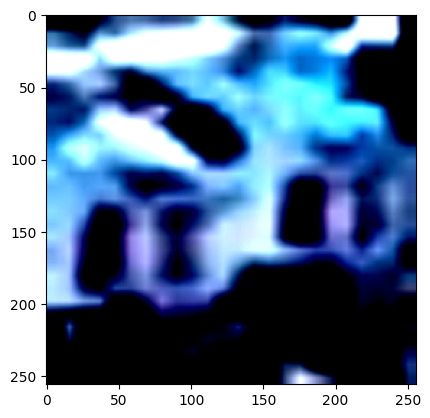

Label: tensor([0., 0., 1., 0., 0.])


In [10]:
#test train dataloader
train_images, train_labels = next(iter(training_data_loader))
print("Features batch shape: " + str(train_images.size()))
print("Labels batch shape: " + str(train_labels.size()))

img = train_images[0].squeeze()
label = train_labels[0]

img_to_plot = img.permute(1, 2, 0)
plt.imshow(img_to_plot)
plt.show()
print("Label: " + str(label))

/tmp/ipykernel_23/396129356.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(label, dtype = torch.float)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


torch.Size([32, 3, 256, 256])
torch.Size([32, 5])


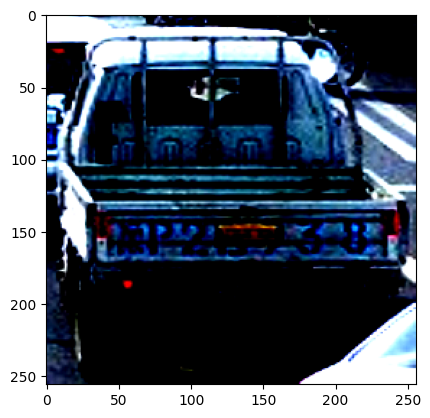

Label tensor([0., 0., 0., 0., 1.])


In [11]:
#test validation set dataloader
val_images, val_labels = next(iter(validation_data_loader))
print(val_images.size())
print(val_labels.size())

img = val_images[0].squeeze()
label = val_labels[0]
img_to_plot = img.permute(1, 2, 0)
plt.imshow(img_to_plot)
plt.show()
print("Label " + str(label))

In [12]:
#CNN model
class CNN(nn.Module):
    
    def __init__(self, in_channels, num_classes):
        """
        Initialize convolutional layers, pooling layers and linear layer
        """
        super(CNN, self).__init__()
        self.conv_layer_1 = nn.Conv2d(in_channels = in_channels, out_channels = 4, kernel_size = 3, padding = 1)
        self.pooling_layer = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.conv_layer_2 = nn.Conv2d(in_channels = 4, out_channels = 8, kernel_size = 3, padding = 1)
        self.hidden_layer_1 = nn.Linear(8 * 64 * 64, 128)
        self.dropout_1 = nn.Dropout(p = 0.5)
        self.last_layer = nn.Linear(128, num_classes)

    def forward(self, x):
        """
        Defines the architecture of a forward pass. 
        This can change depending on validation set metrics.
        2 convolutional layers, 2 pooling layers, 1 dense layer.
        """
        x = activation.relu(self.conv_layer_1(x))
        x = self.pooling_layer(x)
        x = activation.relu(self.conv_layer_2(x))
        x = self.pooling_layer(x)

        #flatten and pass into dense layer
        x = x.reshape(x.shape[0], -1)
        x = activation.relu(self.hidden_layer_1(x))
        s = self.dropout_1(x)
        x = self.last_layer(x)
        
        return x

In [13]:
#initialize cnn model
cnn_model = CNN(in_channels = 3, num_classes = 5)
print(cnn_model)

CNN(
  (conv_layer_1): Conv2d(3, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling_layer): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_layer_2): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (hidden_layer_1): Linear(in_features=32768, out_features=128, bias=True)
  (dropout_1): Dropout(p=0.5, inplace=False)
  (last_layer): Linear(in_features=128, out_features=5, bias=True)
)


In [14]:
e_loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr = 0.0005, weight_decay = .001)

num_epochs = 30

cnn_model.to(device)
#set model to training mode

for epoch in range(num_epochs):
    cnn_model.train()
    
    print("StartingEpoch: " + str(epoch))
    total_samples = 0
    correct_samples = 0
    accumulated_train_loss = 0

    #get batch of 32 images and their corresponding labels from data_loader
    for batch, (data, targets) in enumerate(training_data_loader):

        data = data.to(device)
        targets = targets.to(device)
        #run cnn model on images
        predictions = cnn_model(data)

        #calculate loss
        loss = e_loss(predictions, targets)
        accumulated_train_loss += loss.item()
        
        optimizer.zero_grad()
        
        #backpropogation
        loss.backward()
        optimizer.step()

        #convert to 1d tensor to compare to predicted labels
        targets_indices = torch.argmax(targets, dim=1) 
        _, predicted_classes = torch.max(predictions, 1)
        
        # total samples for training set
        total_samples += targets_indices.size(0)

        #print(targets.shape)
        #print(predicted_classes.shape)
        #print(targets.shape)
        #print(predicted_classes.shape)
        correct_samples += (predicted_classes == targets_indices).sum().item()

    #set model to evaluate mode for validation set
    cnn_model.eval()
    val_total_samples = 0
    val_correct = 0
    accumulated_loss = 0.0


    with torch.no_grad():
        for batch, (val_data, val_targets) in enumerate(validation_data_loader):
            val_data = val_data.to(device)
            val_targets = val_targets.to(device)
            
            val_predictions = cnn_model(val_data)
            val_loss = e_loss(val_predictions, val_targets)
            accumulated_loss += val_loss.item()
            
            val_targets_indices = torch.argmax(val_targets, dim = 1)
            _, val_predicted_classes = torch.max(val_predictions, 1)
            
            val_total_samples += val_targets_indices.size(0)
            val_correct += (val_predicted_classes == val_targets_indices).sum().item()
            
    
    epoch_accuracy = 100 * (correct_samples / total_samples)
    train_average_loss = accumulated_train_loss / len(training_data_loader)
    print("epoch loss: " + str(train_average_loss) + ", accuracy: " + str(epoch_accuracy) + "%")

    val_epoch_accuracy = 100 * (val_correct / val_total_samples)
    val_average_loss = accumulated_loss / len(validation_data_loader)
    print("val epoch loss: " + str(val_average_loss) + ", accuracy: " + str(val_epoch_accuracy) + "%" + "\n")


StartingEpoch: 0


/tmp/ipykernel_23/396129356.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(label, dtype = torch.float)


epoch loss: 1.3987887047585987, accuracy: 45.89041095890411%
val epoch loss: 1.285874530673027, accuracy: 50.86206896551724%

StartingEpoch: 1
epoch loss: 1.234811117251714, accuracy: 52.35920852359208%
val epoch loss: 1.192560188472271, accuracy: 53.879310344827594%

StartingEpoch: 2
epoch loss: 1.187065235206059, accuracy: 54.109589041095894%
val epoch loss: 1.2069526761770248, accuracy: 54.741379310344826%

StartingEpoch: 3
epoch loss: 1.1694697837034862, accuracy: 57.22983257229832%
val epoch loss: 1.2163299918174744, accuracy: 56.03448275862068%

StartingEpoch: 4
epoch loss: 1.121666745060966, accuracy: 56.39269406392694%
val epoch loss: 1.2064996361732483, accuracy: 53.01724137931034%

StartingEpoch: 5
epoch loss: 1.0901346561454592, accuracy: 56.54490106544902%
val epoch loss: 1.1673650592565536, accuracy: 55.172413793103445%

StartingEpoch: 6
epoch loss: 1.0660475095113118, accuracy: 57.458143074581436%
val epoch loss: 1.1378782391548157, accuracy: 54.310344827586206%

Starting